In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('telecom_churn_dataset.csv')

df.head()

,Customer_ID,Age,Gender,City,Tenure_Months,Contract_Type,Internet_Service,Monthly_Charges,Total_Charges,Data_Usage_GB,Call_Minutes,SMS_Count,Customer_Service_Calls,Complaints,Payment_Method,Device_Type,Plan_Type,Auto_Pay,Churn
0,CUST00001,56,Female,Lucknow,31,Month-to-Month,No Internet,383.70,12040.70,0.50,305,38,2,1,Debit Card,Smartphone,Postpaid,No,No
1,CUST00002,69,Male,Delhi,29,Two Year,Fiber Optic,705.88,19993.93,32.84,363,22,0,0,UPI,Smartphone,Prepaid,Yes,No
2,CUST00003,46,Female,Ahmedabad,15,Month-to-Month,DSL,591.65,8663.22,30.31,129,76,0,0,UPI,Smartphone,Prepaid,Yes,No
3,CUST00004,32,Female,Delhi,72,Two Year,DSL,592.20,42496.14,14.04,372,34,1,0,UPI,Smartphone,Postpaid,Yes,No
4,CUST00005,60,Female,Chennai,20,One Year,Fiber Optic,850.52,15688.77,35.07,144,91,0,0,UPI,Smartphone,Prepaid,No,No


In [ ]:
df.shape

(8000, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             8000 non-null   object 
 1   Age                     8000 non-null   int64  
 2   Gender                  8000 non-null   object 
 3   City                    8000 non-null   object 
 4   Tenure_Months           8000 non-null   int64  
 5   Contract_Type           8000 non-null   object 
 6   Internet_Service        8000 non-null   object 
 7   Monthly_Charges         8000 non-null   float64
 8   Total_Charges           7840 non-null   float64
 9   Data_Usage_GB           7880 non-null   float64
 10  Call_Minutes            8000 non-null   int64  
 11  SMS_Count               8000 non-null   int64  
 12  Customer_Service_Calls  8000 non-null   int64  
 13  Complaints              8000 non-null   int64  
 14  Payment_Method          7920 non-null   

In [ ]:
data_quality = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique(),
    'Data Type': df.dtypes
})

data_quality

,Missing Values,Unique Values,Data Type
Customer_ID,0,8000,object
Age,0,52,int64
Gender,0,3,object
City,0,10,object
Tenure_Months,0,73,int64
Contract_Type,0,3,object
Internet_Service,0,3,object
Monthly_Charges,0,7571,float64
Total_Charges,160,7819,float64
Data_Usage_GB,120,4544,float64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Customer_ID'].duplicated().sum()

np.int64(0)

In [ ]:
categorical_columns = [
    'Gender',
    'City',
    'Contract_Type',
    'Internet_Service',
    'Payment_Method',
    'Device_Type',
    'Plan_Type',
    'Auto_Pay',
    'Churn'
]

categorical_summary = pd.DataFrame({
    'Unique Values': [df[col].nunique() for col in categorical_columns],
    'Categories': [df[col].unique() for col in categorical_columns]
}, index=categorical_columns)

categorical_summary

,Unique Values,Categories
Gender,3,"[Female, Male, Other]"
City,10,"[Lucknow, Delhi, Ahmedabad, Chennai, Pune, Mum..."
Contract_Type,3,"[Month-to-Month, Two Year, One Year]"
Internet_Service,3,"[No Internet, Fiber Optic, DSL]"
Payment_Method,5,"[Debit Card, UPI, Net Banking, Credit Card, Ca..."
Device_Type,4,"[Smartphone, Feature Phone, Tablet, Router Only]"
Plan_Type,2,"[Postpaid, Prepaid]"
Auto_Pay,2,"[No, Yes]"
Churn,2,"[No, Yes]"


In [ ]:
#OVERALL  CHURN KPI
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Customers',
        'Churned Customers',
        'Retained Customers',
        'Churn Rate (%)',
        'Average Tenure (Months)',
        'Average Monthly Charges'
    ],
    'Value': [
        df['Customer_ID'].nunique(),
        (df['Churn'] == 'Yes').sum(),
        (df['Churn'] == 'No').sum(),
        round((df['Churn'] == 'Yes').mean() * 100, 2),
        round(df['Tenure_Months'].mean(), 2),
        round(df['Monthly_Charges'].mean(), 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Customers,8000.00
1,Churned Customers,2710.00
2,Retained Customers,5290.00
3,Churn Rate (%),33.88
4,Average Tenure (Months),20.38
5,Average Monthly Charges,670.40


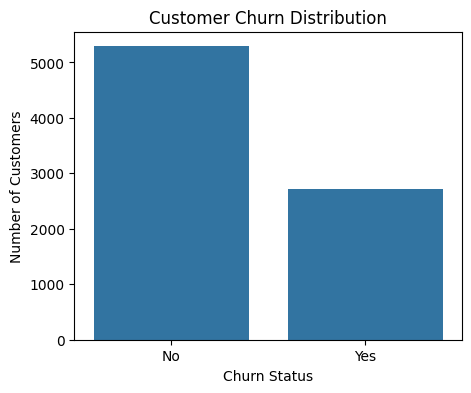

In [ ]:
#CHURN DISTRIBUTION
plt.figure(figsize=(5,4))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5290
Yes,2710


In [ ]:
df['Churn'].value_counts(normalize=True).mul(100).round(2)

,proportion
Churn,
No,66.12
Yes,33.88


In [ ]:
# INSIGHT : 66.12% of customers have remained with the company, while 33.88% have churned.

In [ ]:
# CONTRACT TYPE VS CHURN
contract_churn = pd.crosstab(
    df['Contract_Type'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract_Type,,
Month-to-Month,46.09,53.91
One Year,82.98,17.02
Two Year,97.48,2.52


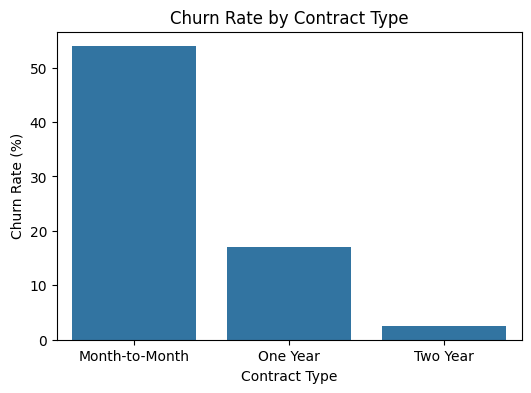

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=contract_churn.index,
    y=contract_churn['Yes']
)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

In [ ]:
#INSIGHT: Month-to-Month contract customers have the highest churn rate at 53.91%, compared with 17.02% for One Year and just 2.52% for Two Year contracts.

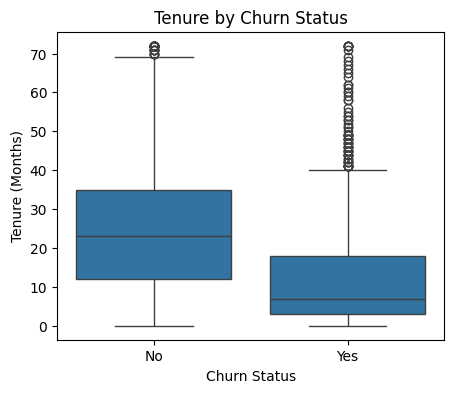

In [ ]:
# TENURE VS CHURN
plt.figure(figsize=(5,4))
sns.boxplot(
    data=df,
    x='Churn',
    y='Tenure_Months'
)
plt.title('Tenure by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.show()

In [ ]:
df.groupby('Churn')['Tenure_Months'].mean().round(2)

,Tenure_Months
Churn,
No,24.95
Yes,11.46


In [ ]:
#INSIGHT: Churned customers have an average tenure of 11.46 months, compared with 24.95 months for retained customers.

In [ ]:
# CHURN RATE BY INTERNET SERVICE
internet_churn = pd.crosstab(
    df['Internet_Service'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn.round(2)

Churn,No,Yes
Internet_Service,,
DSL,71.22,28.78
Fiber Optic,60.34,39.66
No Internet,70.43,29.57


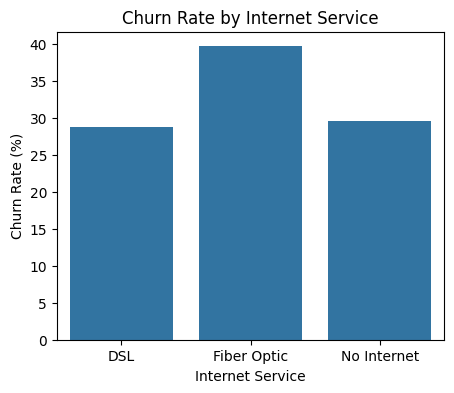

In [ ]:
plt.figure(figsize=(5,4))
sns.barplot(
    x=internet_churn.index,
    y=internet_churn['Yes']
)
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.show()

In [ ]:
#INSIGHT: Fiber Optic customers have the highest churn rate at 39.66%, compared with 28.78% for DSL and 29.57% for customers with no internet service.

In [ ]:
# CHURN RATE BY PAYMENT METHOD
payment_churn = pd.crosstab(
    df['Payment_Method'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn.round(2)

Churn,No,Yes
Payment_Method,,
Cash,59.55,40.45
Credit Card,64.67,35.33
Debit Card,66.14,33.86
Net Banking,66.79,33.21
UPI,69.24,30.76


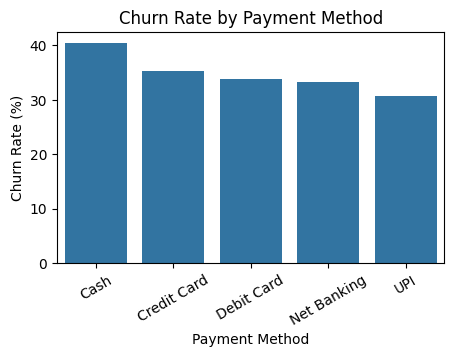

In [ ]:
plt.figure(figsize=(5,3))
sns.barplot(
    x=payment_churn.index,
    y=payment_churn['Yes']
)
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30)
plt.show()

In [ ]:
#INSIGHT : Customers paying by Cash have the highest churn rate at 40.45%, while UPI customers have the lowest at 30.76%.

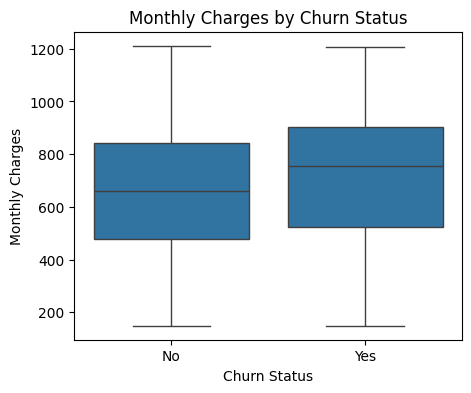

In [ ]:
# MONTHLY CHARGES BY CHURN
plt.figure(figsize=(5,4))
sns.boxplot(
    data=df,
    x='Churn',
    y='Monthly_Charges'
)
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')
plt.show()

In [ ]:
df.groupby('Churn')['Monthly_Charges'].mean().round(2)

,Monthly_Charges
Churn,
No,652.28
Yes,705.78


In [ ]:
#INSIGHT : Churned customers have higher average monthly charges of 705.78, compared with 652.28 among retained customers.

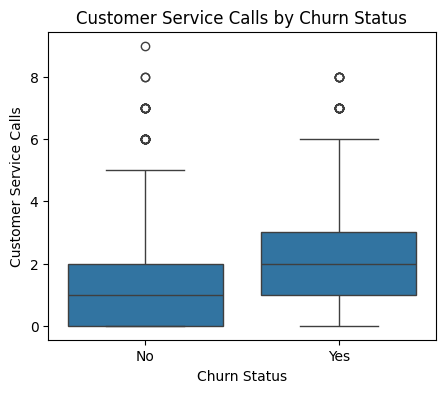

In [ ]:
# CUSTOMER SERVICE CALLS VS COMPLAINTS
#A. Customer Service Calls
plt.figure(figsize=(5,4))
sns.boxplot(
    data=df,
    x='Churn',
    y='Customer_Service_Calls'
)
plt.title('Customer Service Calls by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Customer Service Calls')
plt.show()

In [ ]:
df.groupby('Churn')['Customer_Service_Calls'].mean().round(2)

,Customer_Service_Calls
Churn,
No,1.42
Yes,2.06


In [ ]:
#INSIGHT : Churned customers make an average of 2.06 customer-service calls, compared with 1.42 calls among retained customers.

In [ ]:
#B. Complaints vs Churn
complaint_churn = pd.crosstab(
    df['Complaints'],
    df['Churn'],
    normalize='index'
) * 100

complaint_churn.round(2)

Churn,No,Yes
Complaints,,
0,75.36,24.64
1,60.46,39.54
2,45.54,54.46
3,32.00,68.00
4,37.50,62.50


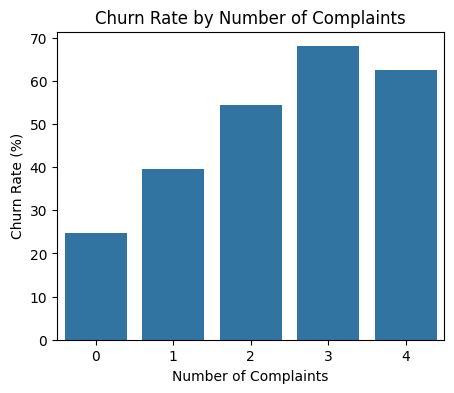

In [ ]:
plt.figure(figsize=(5,4))
sns.barplot(
    x=complaint_churn.index,
    y=complaint_churn['Yes']
)
plt.title('Churn Rate by Number of Complaints')
plt.xlabel('Number of Complaints')
plt.ylabel('Churn Rate (%)')
plt.show()

In [ ]:
#INSIGHT : Churn generally increases as the number of complaints rises, from 24.64% for customers with 0 complaints to 68.00% for customers with 3 complaints. The 4-complaint group is 62.50%.